In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/optimal-control/code/lec7`


In [4]:
using LinearAlgebra
using PyPlot
using LaTeXStrings
using JupyterFormatter
using ControlSystems
import SymPy
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [6]:
# continuous time system
A_c = [0 1; 0 0];
B_c = [0; 1];

In [19]:
# derive discrete time system using matrix exponential
h_sym = SymPy.Sym("h")
D_sym = SymPy.exp([A_c B_c; 0 0 0] * h_sym)

h = 0.1
D = SymPy.convert(Matrix{Float64}, D_sym.subs(h_sym, h))

A = D[1:2, 1:2]
B = D[1:2, 3]

2-element Vector{Float64}:
 0.005000000000000001
 0.1

In [20]:
n = size(A)[2]  # number of states
m = length(size(B)) == 1 ? 1 : size(B)[2]  # number of controls
t_final = 5.0  # final time (try larger values, superlinear in computation complexity increase)
t_history = Array(0:h:t_final)
N = length(t_history)  # number of time steps

51

In [21]:
# initial conditions
x0 = [1.0; 0]  # try some other states

2-element Vector{Float64}:
 1.0
 0.0

In [49]:
# cost weights
Q = 1.0 * I(2)
R = 0.001  # try larger values
Q_N = 1.0 * I(2)

2×2 Diagonal{Float64, Vector{Float64}}:
 1.0   ⋅ 
  ⋅   1.0

In [23]:
function J(x_history, u_history)
    cost = 0.5 * x_history[:, end]' * Q_N * x_history[:, end]
    for k = 1:(N-1)
        cost +=
            0.5 * x_history[:, k]' * Q * x_history[:, k] +
            0.5 * u_history[k]' * R * u_history[k]
    end
    return cost
end

J (generic function with 1 method)

In [34]:
P = zeros(n, n, N)
K = zeros(m, n, N - 1)
P[:, :, end] .= Q_N

# Backward Riccati recursion
for k = (N-1):-1:1
    K[:, :, k] .= (R + B' * P[:, :, k+1] * B) \ (B' * P[:, :, k+1] * A)
    P[:, :, k] .= Q + A' * P[:, :, k+1] * (A - B * K[:, :, k])
end

# Forward rollout starting at x0
x_history = zeros(n, N)
x_history[:, 1] = x0
u_history = zeros(m, N - 1)
for k = 1:(N-1)
    u_history[:, k] .= -K[:, :, k] * x_history[:, k]
    x_history[:, k+1] .= A * x_history[:, k] + B * u_history[k]  # coding tricks: B * u_history[k]
end

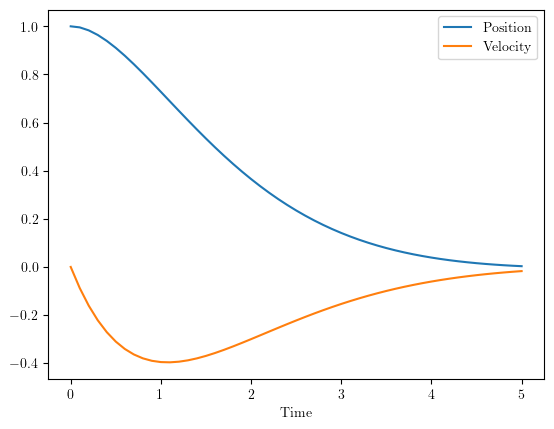

PyObject <matplotlib.legend.Legend object at 0x7f9d8d467a00>

In [46]:
# Plot x1 vs. x2, u vs. t, x vs. t, etc.
plot(t_history, x_history[1, :], label = "Position")
plot(t_history, x_history[2, :], label = "Velocity")
xlabel("Time")
legend()

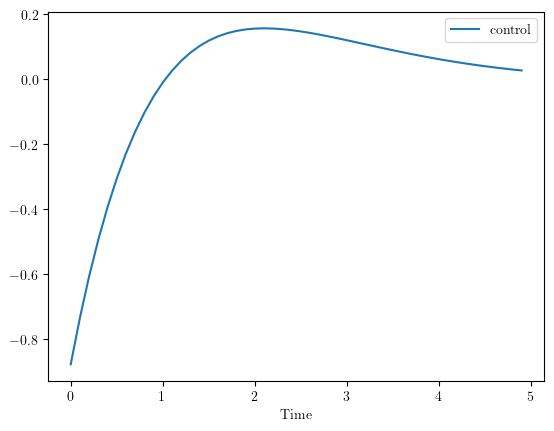

PyObject <matplotlib.legend.Legend object at 0x7f9d8d15aa40>

In [47]:
plot(t_history[1:end-1], u_history[1, :], label = "control")
xlabel("Time")
legend()

In [29]:
J(x_history, u_history)

6.658133166380841

In [35]:
# Forward rollout with random noise
x_history = zeros(n, N)
x_history[:, 1] = x0  # 10.0*randn(2) #Can start anywhere
u_history = zeros(m, N - 1)
for k = 1:(N-1)
    u_history[:, k] .= -K[:, :, k] * x_history[:, k]
    x_history[:, k+1] .= A * x_history[:, k] + B * u_history[k] + 0.01 * randn(2)  # can add noise to dynamics
end

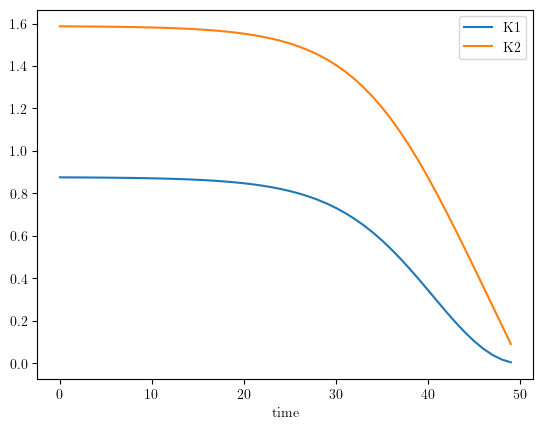

PyObject <matplotlib.legend.Legend object at 0x7f9d8d22dc00>

In [38]:
plot(K[1, 1, :], label = "K1")
plot(K[1, 2, :], label = "K2")
xlabel("time")
legend()

In [50]:
# Compute infinite-horizon K matrix using ControlSystems.jl
# Kinf = dlqr(A, B, Q, R)  # deprecated
Kinf = lqr(Discrete, A, B, Q, R)
# Compare to ours
K[:, :, 1] - Kinf

1×2 Matrix{Float64}:
 -7.85072  -8.08798

In [45]:
# Forward rollout with constant K
x_history = zeros(n, N)
x_history[:, 1] = x0 #Can start anywhere
u_history = zeros(m, N - 1)
for k = 1:(N-1)
    u_history[:, k] .= -Kinf * x_history[:, k]
    x_history[:, k+1] .= A * x_history[:, k] + B * u_history[k] # + 0.01*randn(2)
end

In [51]:
# Closed-loop Eigenvalues (try different Q, R, still keep stable)
eigvals(A - B * Kinf)

2-element Vector{Float64}:
 0.084169448840442
 0.9047163606468936